# Portfolio Optimization Synthetic Demo

This notebook is a prototype that demonstrates random portfolios and efficient-frontier ideas using synthetic return data before moving to real market data.

Read this as a concept notebook for portfolio math rather than a final market study.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import blas, solvers
import pandas as pd

np.random.seed(123)

# Turn off progress printing 
solvers.options['show_progress'] = False

In [39]:
# NUMBER OF ASSETS
n_assets = 5

## NUMBER OF OBSERVATIONS
n_obs = 1000

return_vec = np.random.randn(n_assets, n_obs)

In [41]:
return_vec.T

array([[ 1.14273435,  1.3303492 , -0.95886444, -0.12832407, -1.69727786],
       [ 0.65214869,  1.30575933, -0.79912878,  1.07183336,  0.26869481],
       [ 0.84960517,  0.44901343,  0.3715587 , -1.10748005,  0.77030156],
       ...,
       [ 0.61846629,  0.6636661 , -0.07315591,  0.3932377 ,  1.10675257],
       [ 0.97419439, -0.11423376,  0.43175037,  0.88860378,  0.53831225],
       [ 0.23898088,  0.72720957,  0.56468207, -1.77731282,  1.87093939]])

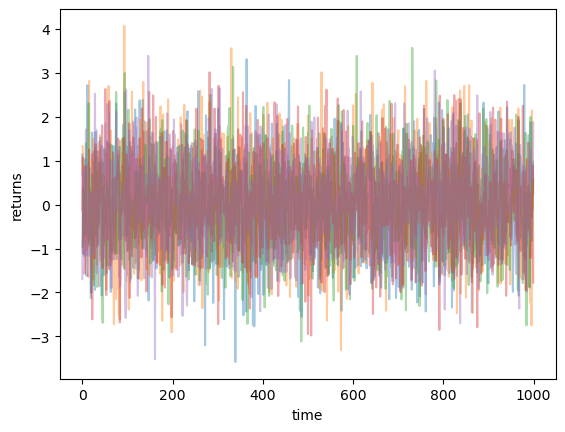

In [43]:
plt.plot(return_vec.T, alpha=.4);
plt.xlabel('time')
plt.ylabel('returns');

In [45]:
def rand_weights(n):
    ''' Produces n random weights that sum to 1 '''
    k = np.random.rand(n)
    return k / sum(k)
    
print (rand_weights(n_assets))
print (rand_weights(n_assets))

[0.16674956 0.1923453  0.13765894 0.18061276 0.32263343]
[0.16177211 0.20661375 0.15518304 0.32054641 0.1558847 ]


In [47]:
def random_portfolio(returns):
    ''' 
    Returns the mean and standard deviation of returns for a random portfolio
    '''
    p = np.asmatrix(np.mean(returns, axis=1))
    w = np.asmatrix(rand_weights(returns.shape[0]))
    C = np.asmatrix(np.cov(returns))
        
    mu = w * p.T
    sigma = np.sqrt(w * C * w.T)
    
    # This recursion reduces outliers to keep plots pretty
    if sigma > 2:
        return random_portfolio(returns)
    return mu, sigma

In [49]:
n_portfolios = 500
means, stds = np.column_stack([
    random_portfolio(return_vec)
    for _ in range(n_portfolios)  # Changed xrange to range
])

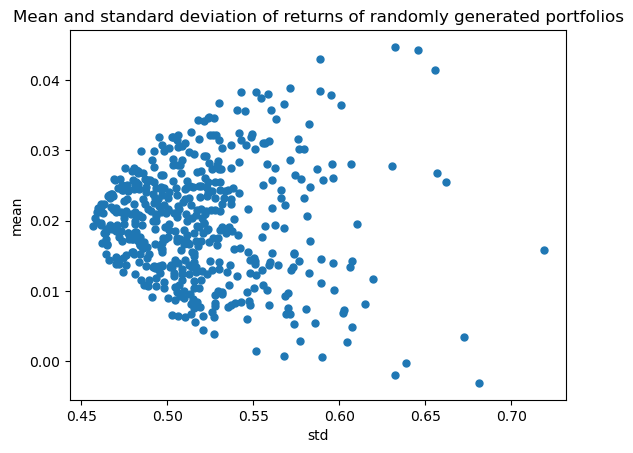

In [51]:
plt.plot(stds, means, 'o', markersize=5)
plt.xlabel('std')
plt.ylabel('mean')
plt.title('Mean and standard deviation of returns of randomly generated portfolios');

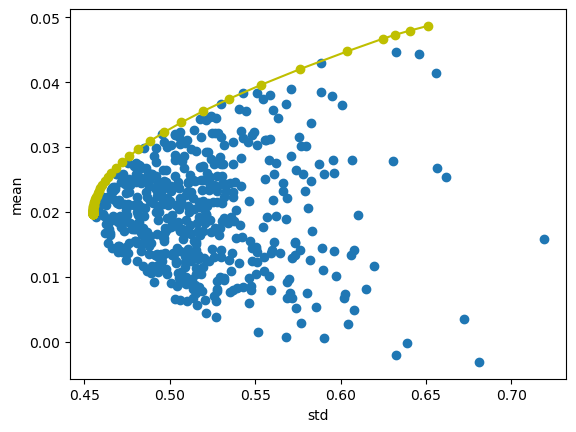

In [53]:
def optimal_portfolio(returns):
    n = len(returns)
    returns = np.asmatrix(returns)
    
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    
    # Convert to cvxopt matrices
    S = opt.matrix(np.cov(returns))
    pbar = opt.matrix(np.mean(returns, axis=1))
    
    # Create constraint matrices
    G = -opt.matrix(np.eye(n))   # negative n x n identity matrix
    h = opt.matrix(0.0, (n ,1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)
    
    # Calculate efficient frontier weights using quadratic programming
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x'] 
                  for mu in mus]
    ## CALCULATE RISKS AND RETURNS FOR FRONTIER
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]
    ## CALCULATE THE 2ND DEGREE POLYNOMIAL OF THE FRONTIER CURVE
    m1 = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    # CALCULATE THE OPTIMAL PORTFOLIO
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return np.asarray(wt), returns, risks

weights, returns, risks = optimal_portfolio(return_vec)

plt.plot(stds, means, 'o')
plt.ylabel('mean')
plt.xlabel('std')
plt.plot(risks, returns, 'y-o');

In [44]:
print (weights)

[[2.77880107e-09]
 [3.20322848e-06]
 [1.54301198e-06]
 [9.99995251e-01]]


In [45]:
import yfinance as yf

In [61]:
tickers = ['MBLY','ARKK','SOFI','NVDA','SHOP','PATH','RXRX']
data = yf.download(
    tickers,
    start='2023-01-01',
    end='2025-02-19',
    auto_adjust = False
)

[*********************100%***********************]  7 of 7 completed


In [67]:
data

Price       Adj Close                                                   \
Ticker           ARKK       MBLY        NVDA   PATH   RXRX        SHOP   
Date                                                                     
2023-01-03  30.208069  32.709999   14.304596  12.29   7.55   35.680000   
2023-01-04  31.517153  31.129999   14.738280  12.45   7.82   37.540001   
2023-01-05  30.763439  30.040001   14.254631  11.38   7.37   35.950001   
2023-01-06  31.110544  31.620001   14.848202  11.70   7.44   36.849998   
2023-01-09  32.538635  33.410000   15.616642  12.70   7.52   37.189999   
...               ...        ...         ...    ...    ...         ...   
2025-02-11  61.349998  17.190001  132.800003  13.98   7.66  123.589996   
2025-02-12  62.680000  16.719999  131.139999  14.12   8.34  120.489998   
2025-02-13  64.779999  17.440001  135.289993  15.14   8.50  127.650002   
2025-02-14  67.019997  17.969999  138.850006  14.93  10.53  128.350006   
2025-02-18  66.480003  18.889999  139.399994  14.90  10.64  129.309998   

Price                      Close                         ...   Open  \
Ticker           SOFI       ARKK       MBLY        NVDA  ...   RXRX   
Date                                                     ...          
2023-01-03   4.500000  30.459999  32.709999   14.315000  ...   7.77   
2023-01-04   4.770000  31.780001  31.129999   14.749000  ...   7.64   
2023-01-05   4.630000  31.020000  30.040001   14.265000  ...   7.75   
2023-01-06   4.620000  31.370001  31.620001   14.859000  ...   7.47   
2023-01-09   4.820000  32.810001  33.410000   15.628000  ...   7.57   
...               ...        ...        ...         ...  ...    ...   
2025-02-11  14.830000  61.349998  17.190001  132.800003  ...   7.48   
2025-02-12  14.770000  62.680000  16.719999  131.139999  ...   7.43   
2025-02-13  15.190000  64.779999  17.440001  135.289993  ...   8.26   
2025-02-14  16.209999  67.019997  17.969999  138.850006  ...   9.17   
2025-02-18  16.830000  66.480003  18.889999  139.399994  ...  11.54   

Price                                Volume                                \
Ticker            SHOP       SOFI      ARKK     MBLY       NVDA      PATH   
Date                                                                        
2023-01-03   35.689999   4.650000  24764600  1950700  401277000   4987800   
2023-01-04   36.290001   4.540000  24025500  3412600  431324000   4808600   
2023-01-05   36.549999   4.660000  15689500  2262300  389168000   5567000   
2023-01-06   36.110001   4.660000  24596200  3841600  405044000   5113800   
2023-01-09   37.700001   4.670000  25848500  4722900  504231000  14356500   
...                ...        ...       ...      ...        ...       ...   
2025-02-11  122.279999  14.990000   6618900  4465600  178902400   8637700   
2025-02-12  119.050003  14.580000  10280300  7696100  160278600   5987300   
2025-02-13  121.000000  14.960000   8663500  3385800  197430000  11063100   
2025-02-14  125.760002  15.410000  10530400  3027200  195479600   7500700   
2025-02-18  129.080002  16.469999   7402900  4174500  219176600   8618200   

Price                                     
Ticker          RXRX      SHOP      SOFI  
Date                                      
2023-01-03   1190100  18847000  29303200  
2023-01-04    765900  20072500  48731400  
2023-01-05    848500  16462100  30512000  
2023-01-06    791700  15951900  31589500  
2023-01-09   1456000  17446600  50435000  
...              ...       ...       ...  
2025-02-11  23896600  34842700  30455200  
2025-02-12  36015000  13307400  33663600  
2025-02-13  29079400  10940300  36477800  
2025-02-14  83547200   8511300  63312400  
2025-02-18  71874500   7251900  53815000  

[533 rows x 42 columns]

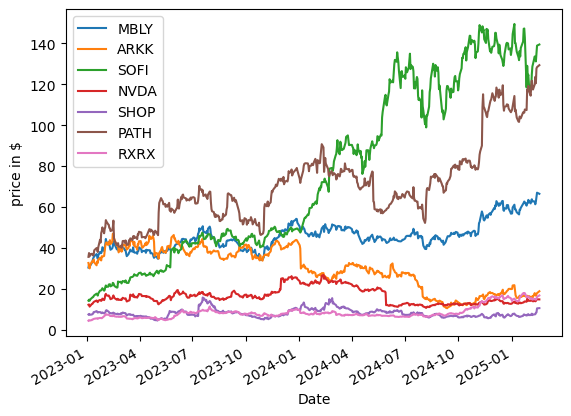

In [75]:
data['Close'].plot()
plt.ylabel('price in $')
plt.legend(tickers);

In [107]:
import zipline
from zipline.api import (
    set_slippage, 
    slippage,
    set_commission, 
    commission, 
    order_target_percent,
    symbols
)

from zipline import TradingAlgorithm

In [113]:
def initialize(context):
    '''
    Called once at the very beginning of a backtest (and live trading). 
    Use this method to set up any bookkeeping variables.
    
    The context object is passed to all the other methods in your algorithm.

    Parameters

    context: An initialized and empty Python dictionary that has been 
             augmented so that properties can be accessed using dot 
             notation as well as the traditional bracket notation.
    
    Returns None
    '''
    # Turn off the slippage model
    set_slippage(slippage.FixedSlippage(spread=0.0))
    # Set the commission model (Interactive Brokers Commission)
    set_commission(commission.PerShare(cost=0.01, min_trade_cost=1.0))
    context.tick = 0
    context.assets = symbols('IBM', 'SBUX', 'XOM', 'AAPL', 'MSFT', 'TLT', 'SHY')
    
def handle_data(context, data):
    '''
    Called when a market event occurs for any of the algorithm's 
    securities. 

    Parameters

    data: A dictionary keyed by security id containing the current 
          state of the securities in the algo's universe.

    context: The same context object from the initialize function.
             Stores the up to date portfolio as well as any state 
             variables defined.

    Returns None
    '''
    
    # Allow history to accumulate 100 days of prices before trading
    # and rebalance every day thereafter.
    context.tick += 1
    if context.tick < 100:
        return
    # Get rolling window of past prices and compute returns
    prices = data.history(context.assets, 'price', 100, '1d').dropna()
    returns = prices.pct_change().dropna()
    try:
        # Perform Markowitz-style portfolio optimization
        weights, _, _ = optimal_portfolio(returns.T)
        # Rebalance portfolio accordingly
        for stock, weight in zip(prices.columns, weights):
            order_target_percent(stock, weight)
    except ValueError as e:
        # Sometimes this error is thrown
        # ValueError: Rank(A) < p or Rank([P; A; G]) < n
        pass
        
# Instantinate algorithm        
algo = TradingAlgorithm(initialize=initialize, 
                        handle_data=handle_data)
# Run algorithm
results = algo.run(data.swapaxes(2, 0, 1))
results.portfolio_value.plot();

TypeError: TradingAlgorithm.__init__() missing 1 required positional argument: 'sim_params'

In [109]:
import yfinance as yf
tickers = ['SOFI', 'HOOD']
df = yf.download(tickers, start = '2022-01-01', end = '2025-02-20')
data = df.Close.copy()

[*********************100%***********************]  2 of 2 completed


In [111]:
returns = np.log(data.pct_change()+1).dropna()

In [113]:
covs = np.asmatrix(np.cov(returns.T))

In [123]:
sigma_s=returns.SOFI.std()
sigma_h=returns.HOOD.std()

In [125]:
mu_s=returns.SOFI.mean()
mu_h=returns.HOOD.mean()

In [137]:
cor = covs/ sigma_s * sigma_h

In [163]:
covs[0,1]/ sigma_s * sigma_h

0.0009567157808418865

In [147]:
returns.HOOD.corr(returns.SOFI)

0.5709225226770772

In [155]:
def covariance(x,y,start,end):
    ticker = [x,y]
    df = yf.download(ticker,start=start,end=end)
    data = df.Close.copy()
    returns_x = np.log(data[x].pct_change() + 1).dropna() #Select the column x and calculate returns
    returns_y = np.log(data[y].pct_change() + 1).dropna() #Select the column y and calculate returns
    # Calculate the covariance between the two return series
    covariance_xy = returns_x.cov(returns_y)

    return covariance_xy